In [11]:
import sys 
from math import floor, ceil
import importlib
sys.path.append('../src')
import main
importlib.reload(main)
%load_ext autoreload
%autoreload 2
import pandas as pd
import sys
print(sys.executable)
from main import DataPipeline

pipeline = DataPipeline()
df = pipeline.pre_process_data()
df_engineered = pd.DataFrame(pipeline.feature_engineering(df))

print(df_engineered.tail())


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
/Users/jordanpickles/opt/miniconda3/envs/whoop-pipeline/bin/python
     recovery_score  resting_heart_rate  hrv_rmssd_milli  skin_temp_celsius  \
929              32                  66        49.468517          33.518000   
930              88                  56        92.045300          34.832000   
931              85                  53        90.351870          34.549503   
932              55                  57        70.583916          34.666164   
933              73                  56        80.926870          34.478333   

     sleep_efficiency_percentage  sleep_consistency_percentage  \
929                    93.511890                          78.0   
930                    92.733670                          76.0   
931                    94.634970                          80.0   
932                    90.468956                          84.0   
933                    94.187750        

# 1.1 Splitting the data
Here a 70/30 split in a temporally ascending order will be taken with a 7 day washout period between these splits to ensure there is data leakage with the 7 day rolling averages.
70:30 split used in this time series dataset to capture any seasonal trends within the data

In [13]:
row_count = len(df_engineered)
row_count_washout_removal = row_count - 7
train_upper_bound = floor(row_count_washout_removal * 0.7)
test_lower_bound = train_upper_bound + 7 
df_engineered = df_engineered.sort_values('date_local').reset_index(drop=True)

train = df_engineered.iloc[7:train_upper_bound]
test = df_engineered.iloc[test_lower_bound:-1]

print(f"Train - Start Date: {train['date_local'].min()} | End Date: {train['date_local'].max()} | Number of Rows: {len(train)} | % of Total Rows: {len(train) / row_count}")
print(f"Test - Start Date: {test['date_local'].min()} | End Date: {test['date_local'].max()} | Number of Rows: {len(test)} | % of Total Rows: {len(test) / row_count}")


Train - Start Date: 2024-01-08 06:26:25.219000 | End Date: 2025-10-08 05:30:49.988000 | Number of Rows: 632 | % of Total Rows: 0.6869565217391305
Test - Start Date: 2025-10-16 05:50:42.653000 | End Date: 2026-07-15 06:03:31.076000 | Number of Rows: 273 | % of Total Rows: 0.2967391304347826


# 1.2 Split out Features and Label
Labels: Recovery Score Shift (-1 day)

In [66]:
features = [col for col in train.columns if col not in ['recovery_score_shift', 'date_local']]
label = 'recovery_score_shift'

X_train = train[features]
y_train = train[label]

X_test = test[features]
y_test = test[label]


print(f"Features: {features}")
print(f"Label: {label}")


Features: ['recovery_score', 'resting_heart_rate', 'hrv_rmssd_milli', 'skin_temp_celsius', 'sleep_efficiency_percentage', 'sleep_consistency_percentage', 'sleep_performance_percentage', 'respiratory_rate', 'sleep_cycle_count', 'disturbance_count', 'sleep_needed_baseline_milli', 'sleep_needed_need_from_recent_strain_milli', 'cycle_strain', 'cycle_avg_heart_rate', 'cycle_kilojoule', 'total_in_bed_time_hours', 'total_rem_sleep_time_hours', 'total_sleep_time_hours', 'hrv_rmssd_milli_rolling_avg_7', 'resting_heart_rate_rolling_avg_7', 'cycle_strain_rolling_avg_7', 'day_of_week', 'sleep_start_local_decimal', 'sleep_end_local_decimal']
Label: recovery_score_shift


# 2.1 Baseline Values



In [67]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
import numpy as np
import pandas as pd

print(f"Lag-1 autocorrelation: {df_engineered['recovery_score'].autocorr(lag=1):.3f}")

Lag-1 autocorrelation: 0.095


It would be a reasonable expectation that recovery scores day to day to persist as most physiological signals do such as periods of increased resting heart rate or surpressed hrv.

However the autocorrelation between day to day recovery scores of 0.095 suggests almost no linear dependence, which is also to be expected based on the variability in day to day behavioural choices. E.g. volume and intensity of exercise and / or variations in sleep duration, quality etc.

In [68]:
naive_pred = X_test['recovery_score']
print(f"Persistence RMSE: {root_mean_squared_error(y_test, naive_pred):.2f}")
print(f"Persistence R2:   {r2_score(y_test, naive_pred):.2f}")

mean_prediction = np.full(shape=len(y_test), fill_value=y_train.mean())
print(f"Mean Prediction RMSE: {root_mean_squared_error(y_test, mean_prediction):.2f}")
print(f"Mean Prediction R2: {r2_score(y_test, mean_prediction):.2f}")


Persistence RMSE: 27.20
Persistence R2:   -0.83
Mean Prediction RMSE: 20.33
Mean Prediction R2: -0.02


The naive baseline of tomorrows recovery = todays recovery performs worse than just taking the mean of the recovery score with an R2 of -0.83 with the mean score of course returning a R2 score of -0.02 (not 0 as the predictions made on the test set to prevent leakeage but provides confidence than the training set is representative of the test set).

The error score of choice used to determine the model which will be selected is RMSE as the main use case of this model is to provide a predicted value allowing the user to plan tomorrow mornings exercise based on the readiness to exercise which the recovery score will be a proxy for. The RMSE error score is to be used as a score close to the mean (e.g. prediction of 65 when the actual was 60) will not impact the training session planned, however a prediction of 70 when the actual value is 40 is a greater issue as it will mean the training sessions planned is not suitable for the physiological state (this is symetric, just as predicting 40 when the actual is 70 would also caused issues). Therefore the RMSE will punish larger errors.

Therefore the aim of the models trained below is to beat the prediction of the mean (RMSE < 20.33).

# 2.2 Linear Regression Models

In [89]:
lr = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('model',  LinearRegression()),
])
lr.fit(X_train, y_train)
y_train_pred_lr = lr.predict(X_train)
y_test_pred_lr = lr.predict(X_test)

print(f"RMSE - Train: {root_mean_squared_error(y_train, y_train_pred_lr):.2f} | Test: {root_mean_squared_error(y_test, y_test_pred_lr):.2f}")
print(f"R2 - Train: {r2_score(y_train, y_train_pred_lr):.2f} | Test: {r2_score(y_test, y_test_pred_lr):.2f}")
print(f"The Linear Model explains {r2_score(y_test, y_test_pred_lr)*100:.2f}% of the variance in tomorrows Recovery Score")

RMSE - Train: 14.74 | Test: 15.99
R2 - Train: 0.48 | Test: 0.37
The Linear Model explains 36.73% of the variance in tomorrows Recovery Score


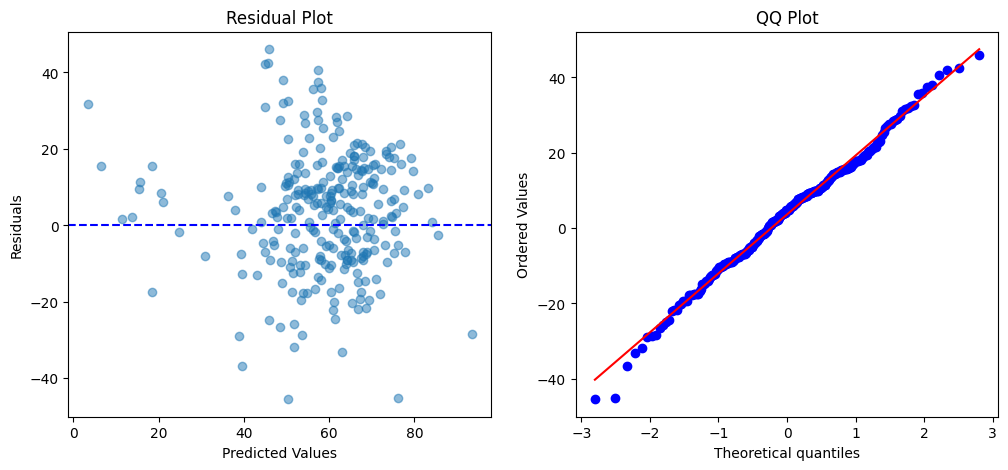

In [70]:
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import probplot


residuals = np.subtract(np.array(y_test), y_pred_lr).astype(float).flatten() # difference between actual and predicted

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,5))
ax1.scatter(y_pred_lr, residuals, alpha=0.5)
ax1.axhline(y=0, color='b', linestyle='--')
ax1.set_xlabel('Predicted Values')
ax1.set_ylabel('Residuals')
ax1.set_title('Residual Plot')

# QQ plot
stats.probplot(residuals, plot=ax2)
ax2.set_title('QQ Plot')



plt.show()

- QQ plot shows that residuals are approximately normally distributed, with some larger misses at the tails, especially at the larger over-predictions, meaning linear assumptions partially hold
- Combined with weak linear correlations across the majority of features, this suggests the relationships are non-linear and potentially conditional on feature interactions (e.g. Sleep Time in combination with resting heart rate etc)

## 2.2.2 Lasso Regression


In [90]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5, gap=7)

lasso = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale',  StandardScaler()),
    ('model',  LassoCV(cv=tscv, random_state=42)),
])
lasso.fit(X_train, y_train)

y_train_pred_lasso = lasso.predict(X_train)
y_test_pred_lasso = lasso.predict(X_test)

print(f"RMSE - Train: {root_mean_squared_error(y_train, y_train_pred_lasso):.2f} | Test: {root_mean_squared_error(y_test, y_test_pred_lasso):.2f} vs baseline 20.33)")
print(f"R2 - Train: {r2_score(y_train, y_train_pred_lasso):.2f} | Test: {r2_score(y_test, y_pred_lasso):.2f}")
print(f"Chosen alpha: {lasso.named_steps['model'].alpha_:.4f}")

/Users/jordanpickles/opt/miniconda3/envs/whoop-pipeline/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:825: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.180100e+01, tolerance: 4.831e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/jordanpickles/opt/miniconda3/envs/whoop-pipeline/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:825: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.323573e+01, tolerance: 4.831e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/jordanpickles/opt/miniconda3/envs/whoop-pipeline/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:825: ConvergenceWarning: Objective did not converge. You might want

RMSE - Train: 14.79 | Test: 15.52 vs baseline 20.33)
R2 - Train: 0.48 | Test: 0.40
Chosen alpha: 0.4760


(273,)


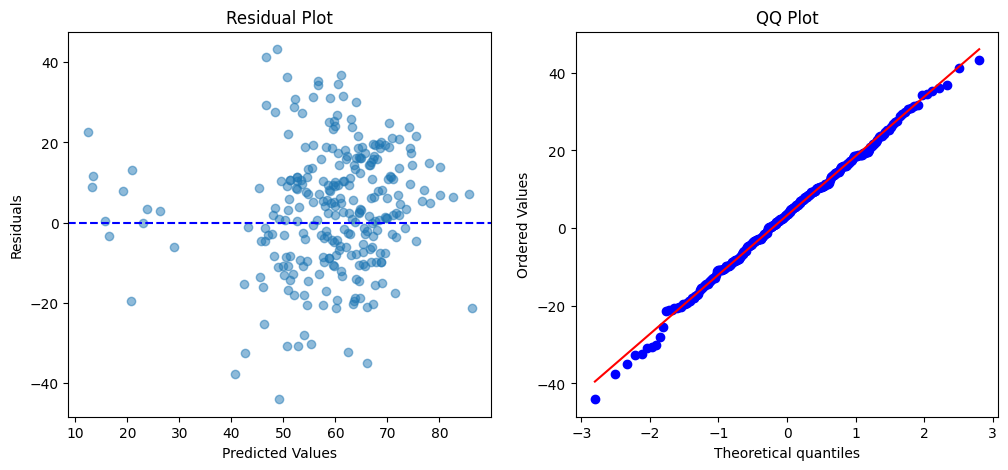

In [ ]:
print(np.array(y_test).shape)
residuals = np.subtract(np.array(y_test), y_test_pred_lasso).astype(float).flatten() # difference between actual and predicted

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,5))
ax1.scatter(y_test_pred_lasso, residuals, alpha=0.5)
ax1.axhline(y=0, color='b', linestyle='--')
ax1.set_xlabel('Predicted Values')
ax1.set_ylabel('Residuals')
ax1.set_title('Residual Plot')

# QQ plot
stats.probplot(residuals, plot=ax2)
ax2.set_title('QQ Plot')



plt.show()

- The QQ lower tail is slightly heavier than the Linear Regression model suggesting a few more overestimates in this model.
- However, on the whole the plots are very similar to the linear regression plots and both have the same issues of some heavier tails than the normal distributions would expect.

In [43]:
import pandas as pd
coefs = pd.Series(
    lasso.named_steps['model'].coef_,
    index=X_train.columns
).sort_values(key=abs, ascending=False)
print(coefs[coefs != 0])          # survivors
print(f"\nDropped {(coefs == 0).sum()} of {len(coefs)} features")

cycle_avg_heart_rate                         -12.527847
resting_heart_rate                             6.282072
recovery_score                                 5.065557
sleep_needed_need_from_recent_strain_milli     2.125018
sleep_consistency_percentage                  -1.964228
respiratory_rate                               1.702575
sleep_start_local_decimal                      1.607500
hrv_rmssd_milli_rolling_avg_7                 -1.337567
disturbance_count                             -0.965389
total_rem_sleep_time_hours                    -0.593730
skin_temp_celsius                             -0.499474
dtype: float64

Dropped 13 of 24 features


The coefficients from the lasso regression above are counterinutitive and go agains the expectations of physiology. For example, the cycle average heart rate being lower is associated with a lower recovery score, whereas the increased resting heart rate is associated with a higher next day recovery score. It is likely that this is caused by some level of colinearity between the metrics as the physiology metrics are highly additive.

As one of the key aims of this work is to provide explainability as to the metrics driving the prediction, the coefficients here suggest this would not be very useful for explainability and therefore a tree based model will be trained in order to use SHAP.

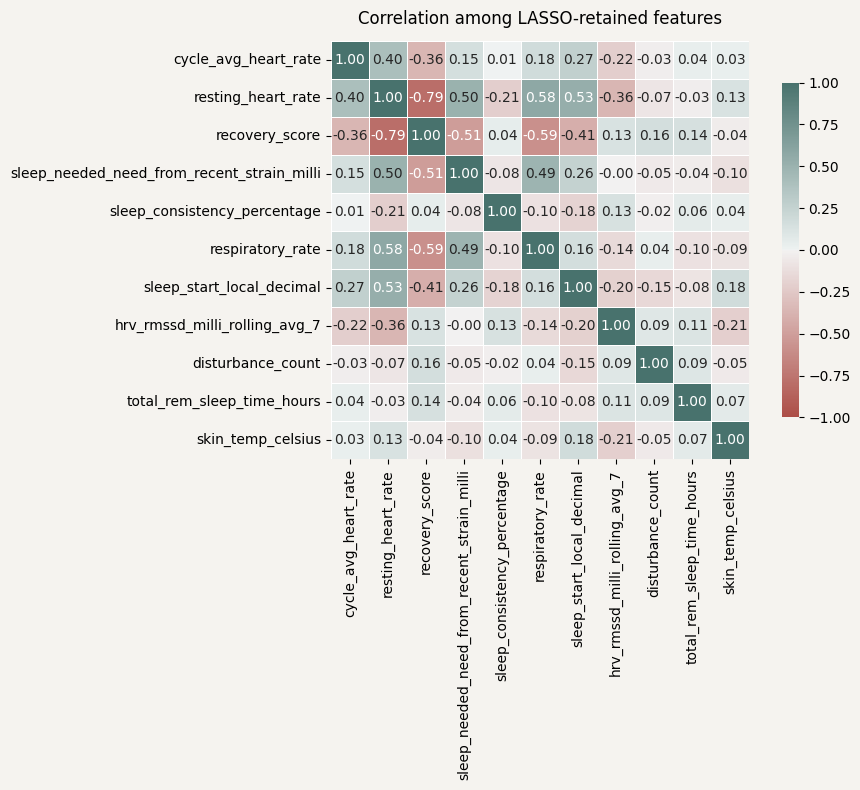

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, ax = plt.subplots(figsize=(10, 8))
corr = X_train[survivors].corr()
fig.patch.set_facecolor('#f5f3ef')
ax.set_facecolor('#f5f3ef')
cmap = sns.diverging_palette(15, 180, s=55, l=45, as_cmap=True)  

sns.heatmap(
    corr,
    annot=True, fmt='.2f',          # numbers in the cells — you want to read exact values
    cmap=cmap,center=0,        # diverging map centred at 0: red=+ve, blue=-ve
    vmin=-1, vmax=1,                # fix the scale so colour = strength consistently
    square=True, linewidths=0.5,
    cbar_kws={'shrink': 0.8},
    ax=ax,
)
ax.set_title('Correlation among LASSO-retained features', pad=12)
plt.tight_layout()
plt.show()

# 2.2 XGBoost Model

## 2.2.1 Baseline Model

In [ ]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

xgb.fit(X_train, y_train)
y_train_pred_xgb = xgb.predict(X_train)
y_test_pred_xgb = xgb.predict(X_test)

print(f"RMSE: Train: {mean_absolute_error(y_train, y_train_pred_xgb):.2f} | Test: {root_mean_squared_error(y_test, y_test_pred_xgb):.2f} vs baseline 20.33")
print(f"R2: Train: {r2_score(y_train, y_train_pred_xgb):.2f} | Test: {r2_score(y_test, y_test_pred_xgb):.2f}")
print(f"The XGBoost model explains {r2_score(y_test, y_pred_xgb)*100:.2f}% of the variance in tomorrows Recovery Score")

MAE: Train: 7.33 | Test: 12.85
RMSE: Train: 7.33 | Test: 15.83 vs baseline 20.33
R2: Train: 0.79 | Test: 0.38
The XGBoost model explains 37.99% of the variance in tomorrows Recovery Score


The metrics on a non-tuned XGBoost model show performance worse on the test set than the Lasso Linear model but interestingly the train RMSE reduced down to 7.33 but with Test remaining in line with the Linear models at 15.83, thus suggesting low bias and high variance. Tuning / optimising the model will hopefully reduce the gap between the RMSE on the train and test set.


## 2.2.2 Model Optimisation

In [80]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from scipy.stats import uniform, randint

param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(2,6),
    'learning_rate': uniform(0.01, 0.2),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'reg_alpha': uniform(0, 1),
    'reg_lambda': uniform(0, 2)
}


tscv = TimeSeriesSplit(n_splits=5, gap=7) # Number of folds, split temporally to ensure it always trains on past folds and validates on future ones

search = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=50,
    scoring='neg_root_mean_squared_error',
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)
print(f"Best params: {search.best_params_}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'colsample_bytree': np.float64(0.8010716092915446), 'learning_rate': np.float64(0.02029575024999787), 'max_depth': 2, 'n_estimators': 323, 'reg_alpha': np.float64(0.9082658859666537), 'reg_lambda': np.float64(0.47912378133394484), 'subsample': np.float64(0.6579579488364892)}


In [94]:
best_xgb = XGBRegressor(**search.best_params_, random_state=42)

best_xgb.fit(X_train, y_train)
y_train_pred_best = best_xgb.predict(X_train)
y_test_pred_best = best_xgb.predict(X_test)

print(f"RMSE - Train: {root_mean_squared_error(y_train, y_train_pred_best):.2f} Test: {root_mean_squared_error(y_test, y_test_pred_best):.2f} vs baseline 20.33")
print(f"R2 - Train: {r2_score(y_train, y_train_pred_best):.2f} Test: {r2_score(y_test, y_test_pred_best):.2f}")

RMSE - Train: 12.98 Test: 15.52 vs baseline 20.33
R2 - Train: 0.60 Test: 0.40


Following tuning, the model saw a small reduction in RMSE reported on the test set but the clear benefit here is the generalisation of the model onto the test set with a reduction in the gap between Train RMSE and Test RMSE down to ~2.5

# 2.2.3 SHAP Analysis

SHAP (SHapley Additive exPlanations) values were used to interpret the tuned XGBoost model. Unlike feature importance scores, SHAP values show the direction and magnitude of each feature's contribution to individual predictions.

/Users/jordanpickles/opt/miniconda3/envs/whoop-pipeline/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


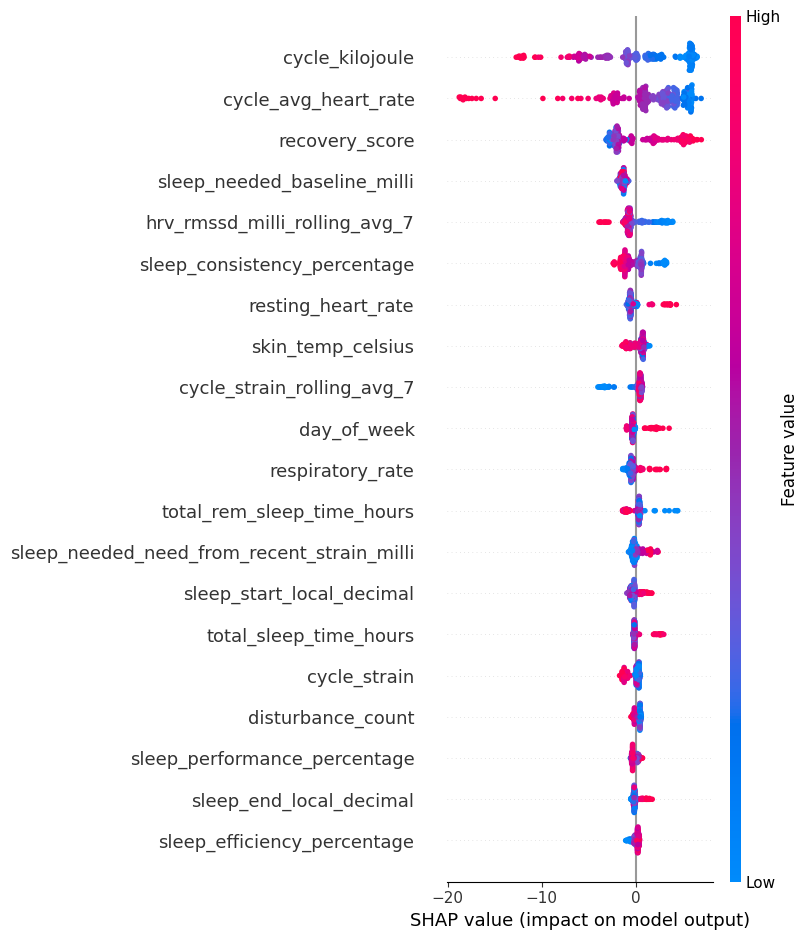

In [82]:
import shap

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

In [83]:
import pandas as pd
feature_groups = {
    'Physiological': [
        'recovery_score',
        'hrv_rmssd_milli',
        'hrv_rmssd_milli_rolling_avg_7',
        'resting_heart_rate',
        'resting_heart_rate_rolling_avg_7',
        'skin_temp_celsius',
        'respiratory_rate'
    ],
    'Training Load': [
        'cycle_strain',
        'cycle_strain_rolling_avg_7',
        'cycle_avg_heart_rate',
        'cycle_kilojoule',
        'day_of_week'
    ],
    'Sleep': [
        'total_sleep_time_hours',
        'total_rem_sleep_time_hours',
        'total_in_bed_time_hours',
        'sleep_efficiency_percentage',
        'sleep_performance_percentage',
        'sleep_consistency_percentage',
        'sleep_start_local_decimal',
        'sleep_end_local_decimal',
        'disturbance_count',
        'sleep_needed_need_from_recent_strain_milli'
    ]
}
shap_df = pd.DataFrame(shap_values, columns=X_test.columns)

group_shap = {}
for group, features in feature_groups.items():
    cols = [f for f in features if f in shap_df.columns]
    group_shap[group] = shap_df[cols].sum(axis=1)

group_shap_df = pd.DataFrame(group_shap)
print(group_shap_df.head())

   Physiological  Training Load     Sleep
0      -3.670120      -5.850883 -0.929749
1      -2.990169       7.567840 -1.412246
2      -2.469257      -8.396642 -3.912817
3      -5.033360       9.690421  0.129067
4       1.285711       1.804993 -0.482017


# 2.3.1 Model Comparison
Four models evaluated on a temporal 70/30 train/test split, with a 7-day embargo
between train and test matching the rolling-window length, to prevent leakage
across the split boundary. 

| Model | Train RMSE | Test RMSE | Test R² |
|---|---|---|---|
| Linear Regression | 14.74 | 15.99 | 0.37 |
| LASSO | 14.79 | 15.52 | 0.40 |
| XGBoost (default) | 7.33 | 15.83 | 0.38 |
| XGBoost (tuned) | 12.98 | 15.52 | 0.40 |

Baseline (mean predictor): RMSE 20.33. Persistence (tomorrow = today): RMSE 27.20,
R² −0.83 — worse than the mean, consistent with near-zero lag-1 autocorrelation (0.095).

### Model convergence
- All four converge at test RMSE ~15.5 despite very different train errors
- Linear models: can't fit train below ~14.8 → a *linearity* ceiling
- Default XGB: train 7.33 / test 15.83 → non-linear structure exists in-sample but doesn't generalise = noise, not signal
- Tuned XGB: regularisation lifts train to 12.98, improves test to 15.52 which converges on the linear result
- Conclusion: hard predictability ceiling ~RMSE 15.5 / R² 0.40 for this individual; which is to be expected with highly variable biological markers and missing data vs when WHOOP calculates the scores e.g. sleep performance etc
- Honest caveat: tuned XGB still fits train ~2pts below LASSO suggesting it can find a structure linear models can't, but it doesn't generalise.

### Model roles
- Selected predictor: LASSO results in equal performance to the XGBoost and is more simple, with a smaller generalisation gap
- Retained for explanation: XGBoost + SHAP: because linear coefficients in the LASSO are distorted by collinearity among physiological features (RHR↔recovery −0.79 flipped RHR's sign)


In [97]:
import joblib
import os
## Saving the model into a .pkl file to be used in the main.py file as a temporary solution
os.makedirs('../models', exist_ok=True)
joblib.dump(best_xgb, '../models/xgboost_model.pkl')
joblib.dump(lasso, '../models/lasso_recovery_model.joblib')
print("Model saved successfully")

Model saved successfully
